# Passive Model Comparison: Does Distinguishing Indifference from Incomparability Help?

## Motivation

The active learning experiments in `BALD_bt_vs_multiframe_experiment.ipynb` conflate two things:
1. **Model quality** — how well does each likelihood use the oracle's responses?
2. **Policy quality** — how well does each query selection strategy choose informative questions?

This notebook isolates (1) by fixing a random set of queries (passive learning) and asking:
> Given the same 60 observations, how well does each model recover the true θ?

## Three Models Compared

All three are fit on **identical data** (same queries, same oracle responses).

| Model | Uses L/R | Uses Indifferent | Uses Incomparable | Distinguishes I vs IC |
|---|---|---|---|---|
| **BT** | ✓ | ✗ | ✗ | — |
| **MF-collapse** | ✓ | ✓ (as 'non-decisive') | ✓ (as 'non-decisive') | ✗ |
| **MF-full** | ✓ | ✓ | ✓ | ✓ |

## Analytic Likelihoods (Logistic Noise, scale_r=0)

For a query with feature gaps `g = λ_x · φ(q)` and weights ω:
- `r(ω) = Σⱼ ωⱼ |gⱼ|` — preference intensity (deterministic, no noise)
- `Δ(ω) = Σⱼ ωⱼ gⱼ` — net utility difference
- `ε_Δ ~ Logistic(0, σ)` — noise on Δ only

Then:
- `P(indifferent) ≈ 1{r < τᵣ}` (hard threshold, smoothed for optimization)
- `P(left)        = sigmoid((Δ - τ_κ·r) / σ)` × 1{r ≥ τᵣ}
- `P(right)       = sigmoid((-Δ - τ_κ·r) / σ)` × 1{r ≥ τᵣ}
- `P(incomparable)= 1 - P(left) - P(right)` × 1{r ≥ τᵣ}

When τ_κ = 0: reduces to pure BT. When τᵣ = 0: no indifference possible.

## Experiment Design

- Fix N oracle weight vectors (sparse Dirichlet draws)
- Fix Q = 60 random queries (shared across all models and all grid cells)
- For each oracle and (τᵣ, τ_κ) in a 5×5 grid:
  - Label the queries using the oracle DGP
  - Fit all three models on subsets of size n ∈ {5, 10, 20, 30, 40, 50, 60}
  - Record cosine similarity and L1 error at each n
- Average over oracles and plot

In [24]:
# ============================================================
# CELL 1: Imports and shared utilities (self-contained)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from dataclasses import dataclass
from typing import List, Tuple, Optional, Callable, Dict
from scipy.optimize import minimize
from scipy.special import expit as sigmoid
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── Constants ────────────────────────────────────────────────
FEATURE_NAMES = ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']
DIM = len(FEATURE_NAMES)
LAMBDA_X = 1.0

# ── Data structures ──────────────────────────────────────────
@dataclass
class Patient:
    elderlyDep: float
    lifeYearsGained: float
    obesity: float
    weeklyWorkhours: float
    yearsWaiting: float

    def to_array(self) -> np.ndarray:
        return np.array([
            self.elderlyDep, self.lifeYearsGained, self.obesity,
            self.weeklyWorkhours, self.yearsWaiting
        ], dtype=float)

@dataclass
class PairwiseQuery:
    patient_left: Patient
    patient_right: Patient

# ── Core helpers ─────────────────────────────────────────────
def phi(query: PairwiseQuery) -> np.ndarray:
    return query.patient_left.to_array() - query.patient_right.to_array()

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na < 1e-10 or nb < 1e-10:
        return 0.0
    return float(np.dot(a, b) / (na * nb))

def l1_error(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.sum(np.abs(a - b)))

def generate_random_patient(rng: np.random.Generator) -> Patient:
    v = rng.uniform(0, 1, size=5)
    return Patient(*v)

def generate_random_queries(n: int, rng: np.random.Generator) -> List[PairwiseQuery]:
    return [PairwiseQuery(generate_random_patient(rng), generate_random_patient(rng))
            for _ in range(n)]

# ── DGP ──────────────────────────────────────────────────────
def dgp_response(
    query: PairwiseQuery,
    omega: np.ndarray,
    tau_r: float,
    tau_kappa: float,
    sigma: float,
    rng: np.random.Generator,
    lambda_x: float = LAMBDA_X,
) -> str:
    """
    Sample one oracle response from the multiframe DGP.
    Logistic noise on Δ only (scale_r = 0).
    """
    gaps = lambda_x * phi(query)
    r = float(np.dot(omega, np.abs(gaps)))
    delta = float(np.dot(omega, gaps))

    if r < tau_r:
        return 'indifferent'

    eps = rng.logistic(0, sigma)
    delta_tilde = delta + eps

    if abs(delta_tilde) < tau_kappa * r:
        return 'incomparable'
    return 'left' if delta_tilde >= tau_kappa * r else 'right'


print(f'Utilities loaded. DIM={DIM}, features={FEATURE_NAMES}')

Utilities loaded. DIM=5, features=['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']


In [25]:
# ============================================================
# CELL 2: Analytic response probabilities
# ============================================================
# Closed-form for logistic noise on Δ only (scale_r = 0).
# The indifference threshold at r = τᵣ is smoothed with a small
# temperature for gradient-based optimization.
# ============================================================

def mf_probs(
    gaps: np.ndarray,
    omega: np.ndarray,
    tau_r: float,
    tau_kappa: float,
    sigma: float,
    smooth_temp: float = 0.015,
) -> np.ndarray:
    """
    Returns [p_left, p_right, p_indifferent, p_incomparable].

    Uses a smooth sigmoid approximation for the r < τᵣ step:
      w_indiff ≈ sigmoid((τᵣ - r) / smooth_temp)
    At smooth_temp=0.015, this is within 0.001 of the hard threshold
    for |r - τᵣ| > 0.05.
    """
    r = float(np.dot(omega, np.abs(gaps)))
    delta = float(np.dot(omega, gaps))
    s = max(sigma, 1e-8)

    # Weight for indifference region (r < τᵣ)
    w_indiff = float(sigmoid((tau_r - r) / smooth_temp)) if tau_r > 0 else 0.0
    w_comp = 1.0 - w_indiff  # weight for r ≥ τᵣ region

    # Conditional probabilities given r ≥ τᵣ
    p_left_cond  = float(sigmoid((delta - tau_kappa * r) / s))
    p_right_cond = float(sigmoid((-delta - tau_kappa * r) / s))
    p_incomp_cond = max(0.0, 1.0 - p_left_cond - p_right_cond)

    return np.array([
        w_comp * p_left_cond,   # p_left
        w_comp * p_right_cond,  # p_right
        w_indiff,               # p_indifferent
        w_comp * p_incomp_cond, # p_incomparable
    ])


# ── Quick sanity checks ───────────────────────────────────────
gaps_test = np.array([1.0, 0.0, 0.0, 0.0, 0.0])
omega_test = np.ones(5) / 5

# τ_κ=0: should reduce to BT (no incomparable)
p = mf_probs(gaps_test, omega_test, tau_r=0.0, tau_kappa=0.0, sigma=1.0)
assert p[3] < 1e-6, f'Expected p_incomp=0 when τ_κ=0, got {p[3]:.4f}'
assert abs(p[0] - sigmoid(0.2)) < 0.01, f'Expected BT left prob, got {p[0]:.4f}'

# τᵣ=1.0, r=0.2: should be almost certain indifference
p = mf_probs(gaps_test, omega_test, tau_r=1.0, tau_kappa=0.25, sigma=1.0)
assert p[2] > 0.99, f'Expected near-certain indifference, got {p[2]:.4f}'

# Probabilities sum to 1
p = mf_probs(gaps_test, omega_test, tau_r=0.1, tau_kappa=0.3, sigma=0.5)
assert abs(p.sum() - 1.0) < 1e-6, f'Probs do not sum to 1: {p.sum():.6f}'

print('Sanity checks passed.')
print(f'Example probs (τᵣ=0.1, τ_κ=0.3, σ=0.5): left={p[0]:.3f}, right={p[1]:.3f}, indiff={p[2]:.3f}, incomp={p[3]:.3f}')

Sanity checks passed.
Example probs (τᵣ=0.1, τ_κ=0.3, σ=0.5): left=0.569, right=0.372, indiff=0.001, incomp=0.058


In [26]:
# ============================================================
# CELL 3: Model fitting
# ============================================================

def fit_mf_map(
    transcript: List[Tuple[PairwiseQuery, str]],
    tau_r: float,
    tau_kappa: float,
    sigma: float,
    mode: str = 'full',
    lambda_x: float = LAMBDA_X,
    l2_reg: float = 1e-2,
    n_restarts: int = 4,
    rng: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """
    Fit MAP estimate for multiframe model variants.

    mode='full'     : 4-category likelihood (distinguishes I from IC)
    mode='collapse' : 3-category likelihood (I and IC → 'non-decisive')

    Uses softmax parameterization for ω (unconstrained → simplex).
    Returns ω̂ on simplex.
    """
    if rng is None:
        rng = np.random.default_rng()
    if len(transcript) == 0:
        return np.ones(DIM) / DIM

    # Precompute gaps for all queries (fixed across restarts)
    gaps_list = [lambda_x * phi(q) for q, _ in transcript]
    responses  = [r for _, r in transcript]

    def neg_log_lik(u: np.ndarray) -> float:
        # ω = softmax(u)
        u_shifted = u - u.max()
        omega = np.exp(u_shifted) / np.exp(u_shifted).sum()

        ll = 0.0
        for gaps, response in zip(gaps_list, responses):
            probs = mf_probs(gaps, omega, tau_r, tau_kappa, sigma)
            # probs: [p_left, p_right, p_indiff, p_incomp]

            if mode == 'full':
                idx = {'left': 0, 'right': 1, 'indifferent': 2, 'incomparable': 3}[response]
                p = max(probs[idx], 1e-15)
            else:  # collapse
                if response == 'left':
                    p = max(probs[0], 1e-15)
                elif response == 'right':
                    p = max(probs[1], 1e-15)
                else:  # indifferent or incomparable → non-decisive
                    p = max(probs[2] + probs[3], 1e-15)

            ll += np.log(p)

        # Light L2 on softmax params (prevents extreme concentrations)
        reg = 0.5 * l2_reg * np.sum(u ** 2)
        return -ll + reg

    best_result = None
    for _ in range(n_restarts):
        u0 = rng.normal(0, 0.5, size=DIM)
        res = minimize(neg_log_lik, u0, method='L-BFGS-B',
                       options={'maxiter': 500, 'ftol': 1e-9})
        if best_result is None or res.fun < best_result.fun:
            best_result = res

    u_opt = best_result.x
    u_opt -= u_opt.max()
    omega_opt = np.exp(u_opt) / np.exp(u_opt).sum()
    return omega_opt


def fit_bt_mle(
    transcript: List[Tuple[PairwiseQuery, str]],
    lambda_x: float = LAMBDA_X,
    l2_reg: float = 1e-2,
    n_restarts: int = 4,
    rng: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """
    Fit BT model (logistic regression) on decisive (left/right) responses.
    Constrained to simplex (ω ≥ 0, Σω = 1) since true θ lives there.
    Learns a scale s jointly with ω to handle unknown oracle noise level.
    L2 reg on softmax params is numerical stabilization only, not a prior.
    Returns ω̂ on simplex.
    """
    if rng is None:
        rng = np.random.default_rng()

    decisive = [(q, r) for q, r in transcript if r in ('left', 'right')]
    if len(decisive) == 0:
        return np.ones(DIM) / DIM

    phis = np.array([lambda_x * phi(q) for q, _ in decisive])
    ys   = np.array([1.0 if r == 'left' else 0.0 for _, r in decisive])

    def neg_log_lik(params: np.ndarray) -> float:
        u = params[:DIM]
        t = params[DIM]
        u_shifted = u - u.max()
        omega = np.exp(u_shifted) / np.exp(u_shifted).sum()
        s = np.log1p(np.exp(np.clip(t, -20, 20)))  # softplus → s > 0

        logits = s * (phis @ omega)
        log_p  = np.where(logits >= 0,
                          -np.log1p(np.exp(-logits)),
                          logits - np.log1p(np.exp(logits)))
        log_1p = np.where(logits >= 0,
                          -logits - np.log1p(np.exp(-logits)),
                          -np.log1p(np.exp(logits)))
        nll = -np.sum(ys * log_p + (1 - ys) * log_1p)
        reg  = 0.5 * l2_reg * np.sum(u ** 2)
        return nll + reg

    best_result = None
    t0_default = np.log(np.exp(1.0) - 1)  # softplus inverse of 1
    for _ in range(n_restarts):
        u0 = rng.normal(0, 0.5, size=DIM)
        params0 = np.concatenate([u0, [t0_default]])
        res = minimize(neg_log_lik, params0, method='L-BFGS-B',
                       options={'maxiter': 500, 'ftol': 1e-9})
        if best_result is None or res.fun < best_result.fun:
            best_result = res

    u_opt = best_result.x[:DIM]
    u_opt -= u_opt.max()
    omega_opt = np.exp(u_opt) / np.exp(u_opt).sum()
    return omega_opt


print('Fitting functions defined: fit_mf_map (full/collapse), fit_bt_mle')

Fitting functions defined: fit_mf_map (full/collapse), fit_bt_mle


In [27]:
# ============================================================
# CELL 4: Single-oracle experiment runner
# ============================================================

MODELS = ['bt', 'mf_collapse', 'mf_full']
MODEL_LABELS = {'bt': 'BT logistic (ignore non-decisive)',
                'mf_collapse': 'MF-collapse (I+IC → non-decisive)',
                'mf_full': 'MF-full (distinguishes I from IC)'}
MODEL_COLORS = {'bt': '#EE6677', 'mf_collapse': '#CCBB44', 'mf_full': '#4477AA'}


def run_one_trial(
    oracle: np.ndarray,
    queries: List[PairwiseQuery],
    tau_r: float,
    tau_kappa: float,
    sigma: float,
    query_counts: List[int],
    rng: np.random.Generator,
    lambda_x: float = LAMBDA_X,
    n_restarts: int = 3,
) -> Dict[str, Dict[str, List[float]]]:
    """
    For a single oracle and fixed query set:
      1. Label all queries using the DGP.
      2. For each n in query_counts, fit all 3 models on transcript[:n].
      3. Return cos_sims and l1s per model per query count.

    All three models see exactly the same transcript prefix.
    """
    # Step 1: Label all queries
    transcript = [
        (q, dgp_response(q, oracle, tau_r, tau_kappa, sigma, rng, lambda_x))
        for q in queries
    ]

    results = {m: {'cos_sims': [], 'l1s': [], 'response_counts': []} for m in MODELS}

    for n in query_counts:
        sub = transcript[:n]
        counts = Counter(r for _, r in sub)
        fit_rng = np.random.default_rng(rng.integers(0, 2**32))

        estimates = {
            'bt':          fit_bt_mle(sub, lambda_x, n_restarts=n_restarts, rng=fit_rng),
            'mf_collapse': fit_mf_map(sub, tau_r, tau_kappa, sigma, mode='collapse',
                                      lambda_x=lambda_x, n_restarts=n_restarts, rng=fit_rng),
            'mf_full':     fit_mf_map(sub, tau_r, tau_kappa, sigma, mode='full',
                                      lambda_x=lambda_x, n_restarts=n_restarts, rng=fit_rng),
        }

        for m, omega_hat in estimates.items():
            results[m]['cos_sims'].append(cosine_similarity(omega_hat, oracle))
            results[m]['l1s'].append(l1_error(omega_hat, oracle))
            results[m]['response_counts'].append(dict(counts))

    return results


def run_grid_sweep(
    taus_r: List[float],
    taus_kappa: List[float],
    n_oracles: int = 10,
    n_queries: int = 60,
    sigma: float = 0.5,
    oracle_seed: int = 42,
    oracle_alpha: float = 0.2,
    query_seed: int = 1234,
    queries: Optional[List[PairwiseQuery]] = None,  # if provided, skips random generation
    query_counts: Optional[List[int]] = None,
    lambda_x: float = LAMBDA_X,
    n_restarts: int = 3,
    verbose: bool = True,
):
    """
    Run the passive model comparison across a (τᵣ, τ_κ) grid.

    Same oracle set and same queries are reused across all grid cells,
    so only the DGP labeling changes.

    Returns: grid_results[(tau_r, tau_kappa)] → averaged results per model
    """
    if query_counts is None:
        query_counts = [5, 10, 15, 20, 30, 40, 50, 60]

    # Fixed oracle set (sparse Dirichlet → peaky weights, harder learning problem)
    oracle_rng = np.random.default_rng(oracle_seed)
    oracles = [oracle_rng.dirichlet(oracle_alpha * np.ones(DIM))
               for _ in range(n_oracles)]

    # Fixed query set (shared across all grid cells)
    if queries is None:
        query_rng = np.random.default_rng(query_seed)
        queries = generate_random_queries(n_queries, query_rng)
    n_queries = len(queries)  # update in case caller passed fewer/more

    grid_results = {}

    for tau_r in taus_r:
        for tau_kappa in taus_kappa:
            if verbose:
                print(f'  τᵣ={tau_r:.2f}, τ_κ={tau_kappa:.2f} ...', end=' ', flush=True)

            # Collect per-model results across all oracle trials
            model_cos = {m: [] for m in MODELS}  # list of per-trial learning curves
            model_l1  = {m: [] for m in MODELS}
            response_dist = []  # avg response distribution at n=n_queries

            for trial_idx, oracle in enumerate(oracles):
                trial_rng = np.random.default_rng(query_seed + trial_idx * 10_000)
                trial_results = run_one_trial(
                    oracle, queries, tau_r, tau_kappa, sigma,
                    query_counts, trial_rng, lambda_x, n_restarts
                )
                for m in MODELS:
                    model_cos[m].append(trial_results[m]['cos_sims'])
                    model_l1[m].append(trial_results[m]['l1s'])
                # Record response distribution at full n
                response_dist.append(trial_results['bt']['response_counts'][-1])

            # Average over oracles
            cell = {'query_counts': query_counts, 'response_dist': response_dist}
            for m in MODELS:
                arr_cos = np.array(model_cos[m])  # (n_oracles, len(query_counts))
                arr_l1  = np.array(model_l1[m])
                cell[m] = {
                    'cos_mean':   arr_cos.mean(axis=0),
                    'cos_stderr': arr_cos.std(axis=0) / np.sqrt(n_oracles),
                    'l1_mean':    arr_l1.mean(axis=0),
                    'l1_stderr':  arr_l1.std(axis=0) / np.sqrt(n_oracles),
                }

            grid_results[(tau_r, tau_kappa)] = cell
            if verbose:
                # Show average response mix at 60 queries for reference
                all_counts = Counter()
                for d in response_dist:
                    all_counts.update(d)
                total = sum(all_counts.values())
                mix = {k: f'{v/total:.0%}' for k, v in all_counts.most_common()}
                print(f'responses: {mix}')

    return grid_results


print('Experiment runners defined.')

Experiment runners defined.


In [28]:
# ============================================================
# CELL 5 (inserted): Load real pairwise queries from person 39
# ============================================================
# Replaces synthetic random queries with actual queries presented
# to a real respondent in the kidney allocation study.
# Features are normalized to [0,1] using the global min/max
# across all respondents and both left/right columns.
# ============================================================

import pandas as pd

PERSON_ID = 39
CSV_PATH  = 'kidney_pairwise_data.csv'

# Global min/max across entire dataset (both l_ and r_ columns)
# so normalization is consistent with the feature space used in training.
FEAT_RANGES = {
    'elderlyDep':      (0,  3),
    'lifeYearsGained': (-1, 25),
    'obesity':         (0,  4),
    'weeklyWorkhours': (0,  50),
    'yearsWaiting':    (1,  7),
}
FEAT_ORDER = ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']


def normalize_val(val: float, feat: str) -> float:
    lo, hi = FEAT_RANGES[feat]
    return (val - lo) / (hi - lo)


def load_queries_for_person(person_id: int, csv_path: str) -> List[PairwiseQuery]:
    """
    Load all pairwise queries shown to a given respondent,
    with features normalized to [0, 1].
    """
    df = pd.read_csv(csv_path)
    person_df = df[df['id'] == person_id].reset_index(drop=True)

    queries = []
    for _, row in person_df.iterrows():
        left  = Patient(**{f: normalize_val(row[f'l_{f}'], f) for f in FEAT_ORDER})
        right = Patient(**{f: normalize_val(row[f'r_{f}'], f) for f in FEAT_ORDER})
        queries.append(PairwiseQuery(left, right))

    return queries


real_queries = load_queries_for_person(PERSON_ID, CSV_PATH)
print(f'Loaded {len(real_queries)} queries for person {PERSON_ID}')

# Preview: show normalized feature diffs for the first 3 queries
print(f'\nFeature differences φ = x_left - x_right (normalized) for first 3 queries:')
for i, q in enumerate(real_queries[:3]):
    print(f'  Query {i+1}: {phi(q).round(3)}')


Loaded 67 queries for person 39

Feature differences φ = x_left - x_right (normalized) for first 3 queries:
  Query 1: [ 0.     0.577  0.5   -1.     0.   ]
  Query 2: [ 0.667  0.     0.    -0.4    0.667]
  Query 3: [-0.667 -0.769  0.25  -0.6   -0.667]


In [29]:
# ============================================================
# CELL 5: Run the grid sweep
# ============================================================

TAUS_R     = [0.0, 0.2, 0.4, 0.6]   # indifference threshold
TAUS_KAPPA = [0.0, 0.2, 0.4, 0.6]   # incomparability threshold
SIGMA      = 0.5                     # logistic noise scale on Δ
N_ORACLES  = 12                      # oracle weight vectors
ORACLE_ALPHA = 1.0                   # Dirichlet concentration: 1.0 = uniform draws, <1 = sparse/peaky, >1 = dense
N_QUERIES  = 60                      # total queries in each trial
QUERY_COUNTS = [5, 10, 15, 20, 30, 40, 50, 60]

print('Running grid sweep...')
print(f'Grid: {len(TAUS_R)} × {len(TAUS_KAPPA)} = {len(TAUS_R)*len(TAUS_KAPPA)} cells')
print(f'N_ORACLES={N_ORACLES}, N_QUERIES={N_QUERIES}, σ={SIGMA}')
print()

grid_results = run_grid_sweep(
    taus_r=TAUS_R,
    taus_kappa=TAUS_KAPPA,
    n_oracles=N_ORACLES,
    n_queries=N_QUERIES,
    sigma=SIGMA,
    oracle_seed=2026,
    oracle_alpha=ORACLE_ALPHA,
    query_seed=999,
    queries=real_queries,  # use person 39's actual queries
    query_counts=QUERY_COUNTS,
    n_restarts=3,
    verbose=True,
)

print('\nDone.')

Running grid sweep...
Grid: 4 × 4 = 16 cells
N_ORACLES=12, N_QUERIES=60, σ=0.5

  τᵣ=0.00, τ_κ=0.00 ... responses: {'left': '50%', 'right': '50%'}
  τᵣ=0.00, τ_κ=0.20 ... responses: {'right': '47%', 'left': '47%', 'incomparable': '7%'}
  τᵣ=0.00, τ_κ=0.40 ... responses: {'left': '43%', 'right': '43%', 'incomparable': '13%'}
  τᵣ=0.00, τ_κ=0.60 ... responses: {'left': '39%', 'right': '39%', 'incomparable': '21%'}
  τᵣ=0.20, τ_κ=0.00 ... responses: {'left': '45%', 'right': '44%', 'indifferent': '10%'}
  τᵣ=0.20, τ_κ=0.20 ... responses: {'left': '42%', 'right': '41%', 'indifferent': '10%', 'incomparable': '7%'}
  τᵣ=0.20, τ_κ=0.40 ... responses: {'left': '40%', 'right': '38%', 'incomparable': '12%', 'indifferent': '10%'}
  τᵣ=0.20, τ_κ=0.60 ... responses: {'left': '36%', 'right': '34%', 'incomparable': '20%', 'indifferent': '10%'}
  τᵣ=0.40, τ_κ=0.00 ... responses: {'indifferent': '55%', 'left': '23%', 'right': '22%'}
  τᵣ=0.40, τ_κ=0.20 ... responses: {'indifferent': '55%', 'left': '20%'

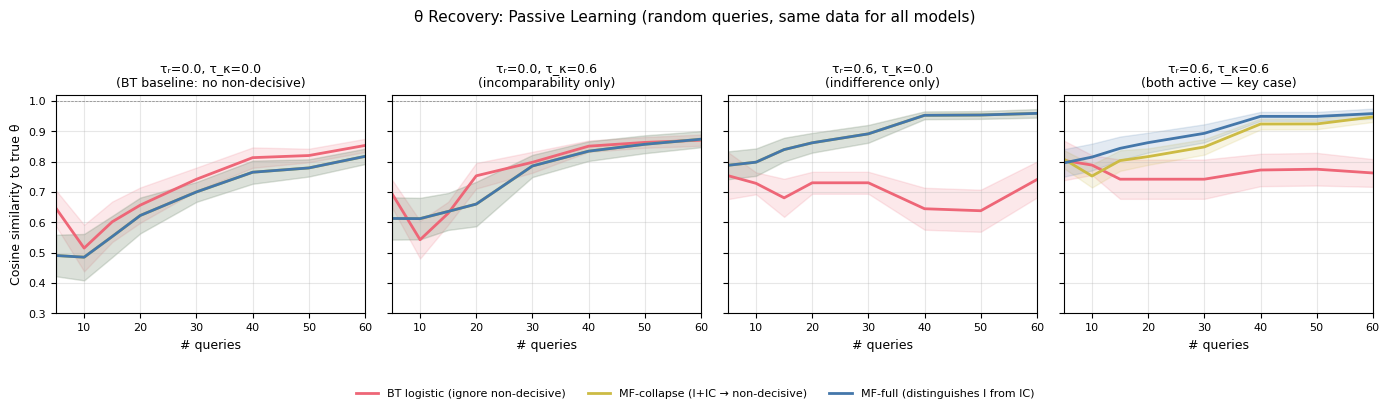

In [30]:
# ============================================================
# CELL 6: Learning curves for selected (τᵣ, τ_κ) pairs
# ============================================================
# Shows cosine similarity vs. number of queries for all 3 models.
# Pick 4 representative cells: (low,low), (low,high), (high,low), (high,high)
# ============================================================

pairs_to_plot = [
    (TAUS_R[0],  TAUS_KAPPA[0]),   # neither threshold active
    (TAUS_R[0],  TAUS_KAPPA[-1]),  # incomparability only
    (TAUS_R[-1], TAUS_KAPPA[0]),   # indifference only
    (TAUS_R[-1], TAUS_KAPPA[-1]),  # both active — the key comparison
]
pair_titles = [
    f'τᵣ={pairs_to_plot[0][0]}, τ_κ={pairs_to_plot[0][1]}\n(BT baseline: no non-decisive)',
    f'τᵣ={pairs_to_plot[1][0]}, τ_κ={pairs_to_plot[1][1]}\n(incomparability only)',
    f'τᵣ={pairs_to_plot[2][0]}, τ_κ={pairs_to_plot[2][1]}\n(indifference only)',
    f'τᵣ={pairs_to_plot[3][0]}, τ_κ={pairs_to_plot[3][1]}\n(both active — key case)',
]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), sharey=True)

for ax, (tau_r, tau_kappa), title in zip(axes, pairs_to_plot, pair_titles):
    cell = grid_results[(tau_r, tau_kappa)]
    x = QUERY_COUNTS

    for m in MODELS:
        mean   = cell[m]['cos_mean']
        stderr = cell[m]['cos_stderr']
        ax.plot(x, mean, color=MODEL_COLORS[m], lw=2, label=MODEL_LABELS[m])
        ax.fill_between(x, mean - stderr, mean + stderr,
                        color=MODEL_COLORS[m], alpha=0.15)

    ax.set_title(title, fontsize=9)
    ax.set_xlabel('# queries', fontsize=9)
    ax.set_xlim([QUERY_COUNTS[0], QUERY_COUNTS[-1]])
    ax.set_ylim([0.3, 1.02])
    ax.axhline(1.0, color='gray', lw=0.5, ls='--')
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=8)

axes[0].set_ylabel('Cosine similarity to true θ', fontsize=9)

# Single legend below
handles = [plt.Line2D([0], [0], color=MODEL_COLORS[m], lw=2)
           for m in MODELS]
fig.legend(handles, [MODEL_LABELS[m] for m in MODELS],
           loc='lower center', ncol=3, fontsize=8, frameon=False,
           bbox_to_anchor=(0.5, -0.12))

plt.suptitle('θ Recovery: Passive Learning (random queries, same data for all models)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

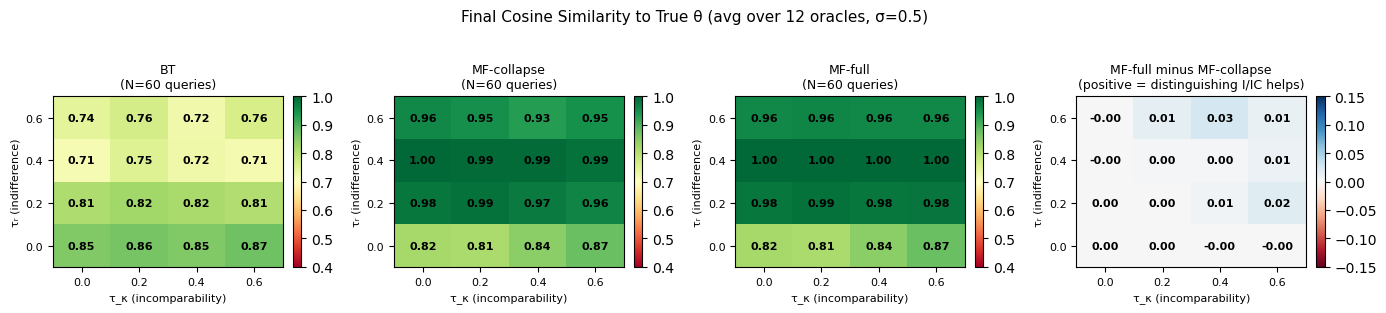

In [31]:
# ============================================================
# CELL 7: Heatmaps of final cosine similarity over (τᵣ, τ_κ) grid
# ============================================================
# Shows where each model succeeds or degrades.
# The difference plot (bottom right) is the key diagnostic:
# positive = MF-full beats MF-collapse, i.e., distinguishing I from IC helps.
# ============================================================

def extract_final_grid(grid_results, metric='cos_mean'):
    """Extract final-query-count values into a matrix indexed by (τᵣ, τ_κ)."""
    data = {m: np.zeros((len(TAUS_R), len(TAUS_KAPPA))) for m in MODELS}
    for i, tr in enumerate(TAUS_R):
        for j, tk in enumerate(TAUS_KAPPA):
            cell = grid_results[(tr, tk)]
            for m in MODELS:
                data[m][i, j] = cell[m][metric][-1]  # final query count
    return data


final_cos = extract_final_grid(grid_results, 'cos_mean')

fig, axes = plt.subplots(1, 4, figsize=(14, 3.0))

vmin, vmax = 0.4, 1.0
cmap = 'RdYlGn'

plot_items = [
    ('bt',          f'BT\n(N={N_QUERIES} queries)',          cmap, vmin, vmax),
    ('mf_collapse', f'MF-collapse\n(N={N_QUERIES} queries)', cmap, vmin, vmax),
    ('mf_full',     f'MF-full\n(N={N_QUERIES} queries)',     cmap, vmin, vmax),
    ('diff',        'MF-full minus MF-collapse\n(positive = distinguishing I/IC helps)', 'RdBu', -0.15, 0.15),
]

for ax, (key, title, cmap_i, v0, v1) in zip(axes, plot_items):
    if key == 'diff':
        mat = final_cos['mf_full'] - final_cos['mf_collapse']
    else:
        mat = final_cos[key]

    im = ax.imshow(mat, origin='lower', aspect='auto',
                   cmap=cmap_i, vmin=v0, vmax=v1,
                   extent=[-0.5, len(TAUS_KAPPA)-0.5, -0.5, len(TAUS_R)-0.5])

    # Annotate cells
    for i in range(len(TAUS_R)):
        for j in range(len(TAUS_KAPPA)):
            val = mat[i, j]
            txt_color = 'white' if (key != 'diff' and val < 0.65) else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color=txt_color, fontweight='bold')

    ax.set_xticks(range(len(TAUS_KAPPA)))
    ax.set_xticklabels([f'{v:.1f}' for v in TAUS_KAPPA], fontsize=8)
    ax.set_yticks(range(len(TAUS_R)))
    ax.set_yticklabels([f'{v:.1f}' for v in TAUS_R], fontsize=8)
    ax.set_xlabel('τ_κ (incomparability)', fontsize=8)
    ax.set_ylabel('τᵣ (indifference)', fontsize=8)
    ax.set_title(title, fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f'Final Cosine Similarity to True θ (avg over {N_ORACLES} oracles, σ={SIGMA})',
             fontsize=11, y=1.03)
plt.tight_layout()
plt.show()

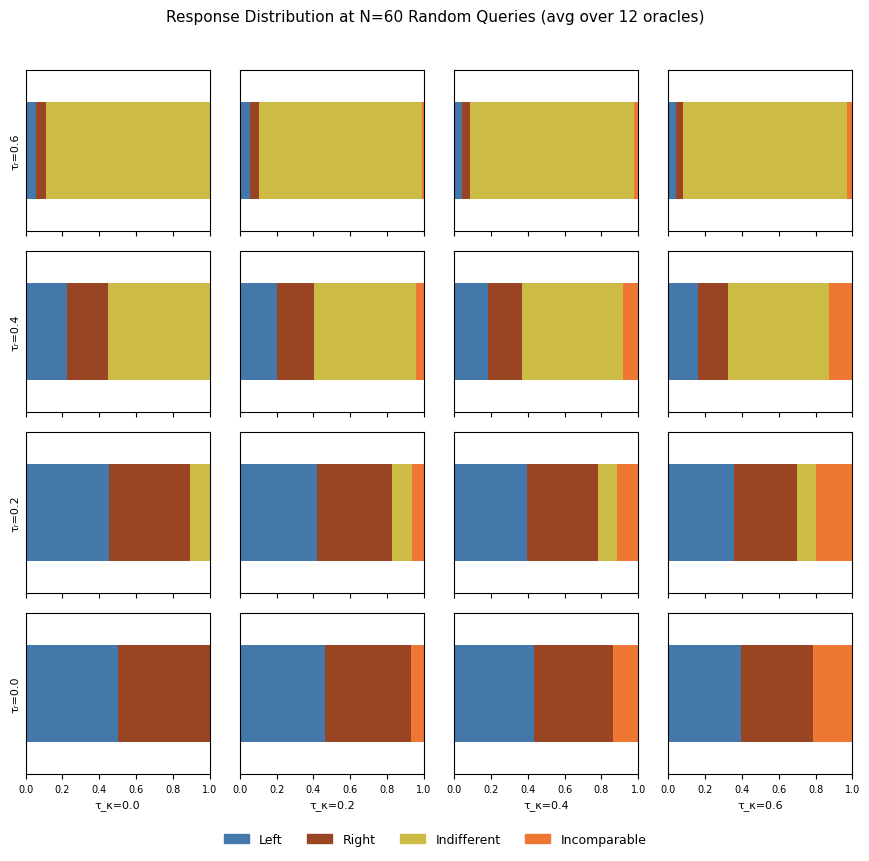

In [32]:
# ============================================================
# CELL 8: Response distribution over the grid
# ============================================================
# Shows how often each response type appears in the 60 queries,
# as a function of (τᵣ, τ_κ). Helps interpret the recovery plots.
# ============================================================

response_types = ['left', 'right', 'indifferent', 'incomparable']
response_colors = {
    'left': '#4477AA', 'right': '#994422',
    'indifferent': '#CCBB44', 'incomparable': '#EE7733',
}

fig, axes = plt.subplots(len(TAUS_R), len(TAUS_KAPPA),
                         figsize=(2.2 * len(TAUS_KAPPA), 2.0 * len(TAUS_R)),
                         sharex=True, sharey=True)

for i, tau_r in enumerate(TAUS_R):
    for j, tau_kappa in enumerate(TAUS_KAPPA):
        ax = axes[len(TAUS_R) - 1 - i, j]  # τᵣ increases upward
        cell = grid_results[(tau_r, tau_kappa)]

        # Average response counts across oracles at full N
        avg_counts = Counter()
        for d in cell['response_dist']:
            avg_counts.update(d)
        total = max(sum(avg_counts.values()), 1)

        fracs = [avg_counts.get(r, 0) / total for r in response_types]
        left_edge = 0
        for frac, rt in zip(fracs, response_types):
            ax.barh(0, frac, left=left_edge, height=0.6,
                    color=response_colors[rt])
            left_edge += frac

        ax.set_xlim([0, 1])
        ax.set_ylim([-0.5, 0.5])
        ax.set_yticks([])
        ax.tick_params(labelsize=7)

        if len(TAUS_R) - 1 - i == len(TAUS_R) - 1:
            ax.set_xlabel(f'τ_κ={tau_kappa:.1f}', fontsize=8)
        if j == 0:
            ax.set_ylabel(f'τᵣ={tau_r:.1f}', fontsize=8)

handles = [plt.Rectangle((0,0),1,1, color=response_colors[r]) for r in response_types]
fig.legend(handles, [r.capitalize() for r in response_types],
           loc='lower center', ncol=4, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.04))

plt.suptitle(f'Response Distribution at N={N_QUERIES} Random Queries (avg over {N_ORACLES} oracles)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

Running focused regime: τᵣ=0.1, τ_κ ∈ [0.0, 0.3, 0.6, 0.9]

  τᵣ=0.10, τ_κ=0.00 ... responses: {'left': '49%', 'right': '49%', 'indifferent': '2%'}
  τᵣ=0.10, τ_κ=0.30 ... responses: {'left': '45%', 'right': '43%', 'incomparable': '10%', 'indifferent': '2%'}
  τᵣ=0.10, τ_κ=0.60 ... responses: {'left': '39%', 'right': '39%', 'incomparable': '20%', 'indifferent': '2%'}
  τᵣ=0.10, τ_κ=0.90 ... responses: {'left': '35%', 'right': '33%', 'incomparable': '30%', 'indifferent': '2%'}


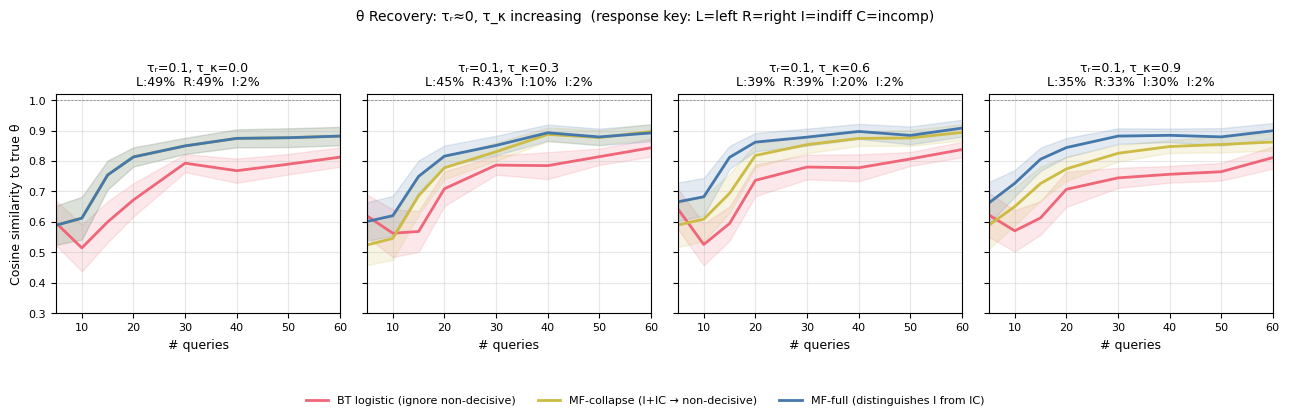

In [34]:
# ============================================================
# CELL: Focused regime — τᵣ ≈ 0, τ_κ large
# ============================================================
# In this regime: almost no indifference (τᵣ ≈ 0), lots of
# incomparable responses (large τ_κ).
#
# Note: |Δ| ≤ r always (triangle inequality), so τ_κ → 1
# means nearly all r≥τᵣ queries become incomparable.
# MF-full ≈ MF-collapse here (no indifference to distinguish),
# so the key comparison is BT vs. both MF variants.
# ============================================================

taus_kappa_focused = [0.0, 0.3, 0.6, 0.9]
tau_r_focused = 0.1  # effectively zero

print(f'Running focused regime: τᵣ={tau_r_focused}, τ_κ ∈ {taus_kappa_focused}')
print()

focused_results = run_grid_sweep(
    taus_r=[tau_r_focused],
    taus_kappa=taus_kappa_focused,
    n_oracles=N_ORACLES,
    n_queries=N_QUERIES,
    sigma=SIGMA,
    oracle_seed=2026,
    oracle_alpha=ORACLE_ALPHA,
    query_seed=999,
    queries=real_queries,
    query_counts=QUERY_COUNTS,
    n_restarts=3,
    verbose=True,
)

# ── Plot learning curves ──────────────────────────────────────
fig, axes = plt.subplots(1, len(taus_kappa_focused), figsize=(13, 3.5), sharey=True)

for ax, tau_kappa in zip(axes, taus_kappa_focused):
    cell = focused_results[(tau_r_focused, tau_kappa)]
    x = QUERY_COUNTS

    for m in MODELS:
        mean   = cell[m]['cos_mean']
        stderr = cell[m]['cos_stderr']
        ax.plot(x, mean, color=MODEL_COLORS[m], lw=2, label=MODEL_LABELS[m])
        ax.fill_between(x, mean - stderr, mean + stderr,
                        color=MODEL_COLORS[m], alpha=0.15)

    # Annotate response mix at N=60
    all_counts = {}
    for d in cell['response_dist']:
        for k, v in d.items():
            all_counts[k] = all_counts.get(k, 0) + v
    total = sum(all_counts.values())
    mix_str = '  '.join(f'{k[0].upper()}:{v/total:.0%}'
                        for k, v in sorted(all_counts.items(), key=lambda x: -x[1]))

    ax.set_title(f'τᵣ={tau_r_focused}, τ_κ={tau_kappa}\n{mix_str}', fontsize=9)
    ax.set_xlabel('# queries', fontsize=9)
    ax.set_xlim([QUERY_COUNTS[0], QUERY_COUNTS[-1]])
    ax.set_ylim([0.3, 1.02])
    ax.axhline(1.0, color='gray', lw=0.5, ls='--')
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=8)

axes[0].set_ylabel('Cosine similarity to true θ', fontsize=9)

handles = [plt.Line2D([0],[0], color=MODEL_COLORS[m], lw=2) for m in MODELS]
fig.legend(handles, [MODEL_LABELS[m] for m in MODELS],
           loc='lower center', ncol=3, fontsize=8, frameon=False,
           bbox_to_anchor=(0.5, -0.14))

plt.suptitle(f'θ Recovery: τᵣ≈0, τ_κ increasing  (response key: L=left R=right I=indiff C=incomp)',
             fontsize=10, y=1.02)
plt.tight_layout()
plt.show()


## Interpreting the Results

**What to look for:**

1. **Learning curves (Cell 6):** In the `(τᵣ=0, τ_κ=0)` panel all three models should perform identically — no non-decisive responses exist, so there's nothing to differentiate. Moving to high τᵣ and/or τ_κ should open a gap between BT (which discards all non-decisive data) and the MF models.

2. **Heatmaps (Cell 7):** The `MF-full minus MF-collapse` panel is the key result. Cells with large positive values identify the regime where distinguishing indifference from incomparability specifically helps, beyond just "not throwing away non-decisive responses."

3. **Response distribution (Cell 8):** Use this as a sanity check. If a cell shows almost no indifferent or incomparable responses (e.g., τᵣ=0), then of course there's no gap between MF-collapse and MF-full.

**Why MF-full can beat MF-collapse:**

- **Indifferent** response → tells the model: `r(ω) = Σⱼ ωⱼ|gⱼ| < τᵣ`, i.e., ω assigns *low weight to features where the gap is large*.
- **Incomparable** response → tells the model: `r(ω) ≥ τᵣ` AND `|Δ̃| ≈ 0`, i.e., items differ meaningfully but in *opposing directions that nearly cancel* under ω.

These are geometrically distinct constraints on ω. When MF-collapse pools them as "non-decisive," it loses the signal that separates these two cases. MF-full preserves it.

**Null hypothesis:** If the `MF-full minus MF-collapse` heatmap is flat near zero everywhere, that means the marginal value of distinguishing I from IC is small — and the paper's main claim about the distinction may need to be reframed.